In [7]:
import os

# Path to your dataset folder in Kaggle
# Example: /kaggle/input/roman-urdu-emotions/
DATA_PATH = "/kaggle/input/jazbatai-data"

# List all files in the directory (max 5)
files = [f for f in os.listdir(DATA_PATH) if os.path.isfile(os.path.join(DATA_PATH, f))]
files = files[:5]  # take only first 5

print("Found files:", files)
print("============================================")

def count_sentences_blank_line(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        content = f.read()

    # Split by double newlines (blank lines)
    sentences = [s.strip() for s in content.split("\n\n") if s.strip()]

    return len(sentences)
# Process each file
for file_name in files:
    full_path = os.path.join(DATA_PATH, file_name)
    
    num_sentences = count_sentences_blank_line(full_path)
    
    print(f"File: {file_name}")
    print(f"Number of sentences (blank-line separated): {num_sentences}")
    print("--------------------------------------------")


Found files: ['training_data_sarcasam.txt', 'training_data_joy.txt', 'training_data_anger.txt', 'training_data_sadness.txt', 'training_data_neutral.txt']
File: training_data_sarcasam.txt
Number of sentences (blank-line separated): 932
--------------------------------------------
File: training_data_joy.txt
Number of sentences (blank-line separated): 1529
--------------------------------------------
File: training_data_anger.txt
Number of sentences (blank-line separated): 999
--------------------------------------------
File: training_data_sadness.txt
Number of sentences (blank-line separated): 1110
--------------------------------------------
File: training_data_neutral.txt
Number of sentences (blank-line separated): 1031
--------------------------------------------


In [8]:
# Import all necessary libraries
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
import time
from sklearn.preprocessing import LabelEncoder

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [9]:
# List available files in the dataset
print("📁 Available files in jazbatAI_data dataset:")
for dirname, _, filenames in os.walk('/kaggle/input/jazbatai-data'):
    for filename in filenames:
        print(f"  📄 {filename}")

📁 Available files in jazbatAI_data dataset:
  📄 training_data_sarcasam.txt
  📄 training_data_joy.txt
  📄 training_data_anger.txt
  📄 training_data_sadness.txt
  📄 training_data_neutral.txt


🚀 Starting data loading process...
🔄 Loading emotion data...
   ✅ training_data_anger.txt: 999 samples loaded as 'anger'
   ✅ training_data_joy.txt: 1529 samples loaded as 'joy'
   ✅ training_data_sadness.txt: 1110 samples loaded as 'sadness'
   ✅ training_data_sarcasam.txt: 932 samples loaded as 'sarcasm'
   ✅ training_data_neutral.txt: 1031 samples loaded as 'neutral'

📊 Dataset Summary:
   Total samples: 5601
   Emotions distribution:
      joy: 1529 samples
      sadness: 1110 samples
      neutral: 1031 samples
      anger: 999 samples
      sarcasm: 932 samples


In [11]:
# Data verifying giving sample data from each emotion and checking for any missing data
print("🔍 Data Exploration:")
print(f"\n📝 Sample texts from each emotion:")
for emotion in df['emotion'].unique():
    samples = df[df['emotion'] == emotion]['text'].head(2)
    print(f"\n{emotion.upper()}:")
    for i, sample in enumerate(samples):
        print(f"   {i+1}. {sample}")

# Check for missing values
print(f"\n🧹 Data Quality Check:")
print(f"   Missing values in text: {df['text'].isnull().sum()}")
print(f"   Missing values in emotion: {df['emotion'].isnull().sum()}")
print(f"   Empty texts: {df['text'].str.strip().eq('').sum()}")

🔍 Data Exploration:

📝 Sample texts from each emotion:

ANGER:
   1. Mujhe samajh nahi aata log itne laaparwah kyun hote hain.
   2. jis tarah usne baat ki, mera pura din barbaad ho gaya.

JOY:
   1. excellent i like it and going to purchase one more
   2. zabardast...dera maza ba oki...

SADNESS:
   1. ye kia tareeka ha per order 1 kg potato only , agr aplog k halat kharab hain tu company bund kardo bhai logo ko pareshan kq kr rahe ho , is tarha per order per kg not acceptable
   2. they never told & mention that how much alcohol % used on that sanitizer, worst sanitizer i've ever purchase ! never recommended !, who recommends minimum 60%

SARCASM:
   1. “Bohat acha, traffic phir se jam”
   2. “Wow, birthday surprise spoil ho gaya”

NEUTRAL:
   1. I think Subah ka traffic signal green hua aur gaadiyan apne raste nikal gayeen..
   2. From what I saw, It appears that Daftar mein naye employees ke liye orientation program agle Mahine ke pehle hafte tak schedule hai..

🧹 Data Quality Chec

In [17]:
# Data Finalization 
import pandas as pd
import numpy as np
import os
import re
from sklearn.model_selection import train_test_split

# -------------------------------
# CONFIG: FILES AND LABELS
# -------------------------------
file_config = {
    '/kaggle/input/jazbatai-data/training_data_joy.txt': 'joy',
    '/kaggle/input/jazbatai-data/training_data_sadness.txt': 'sadness', 
    '/kaggle/input/jazbatai-data/training_data_sarcasam.txt': 'sarcasm',
    '/kaggle/input/jazbatai-data/training_data_anger.txt': 'anger',
    '/kaggle/input/jazbatai-data/training_data_neutral.txt': 'neutral'
}

# -------------------------------
# CREATE OUTPUT FOLDER
# -------------------------------
output_folder = '/kaggle/input/jazbatai-data/labelled-data/'

# Make folder if it doesn't exist
output_folder = '/kaggle/working/labelled-data/'
os.makedirs(output_folder, exist_ok=True)


# -------------------------------
# PROCESS FILES
# -------------------------------
for file_path, emotion_label in file_config.items():
    try:
        cleaned_lines = []

        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f.readlines():
                text = line.strip()
                if not text:
                    continue  # skip empty lines

                # --- Remove Unicode & garbage text ---
                text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # Non-ASCII
                text = re.sub(r'ï¿½+', ' ', text)  # specific garbage
                text = re.sub(r'[ ]+', ' ', text)  # multiple spaces -> single space
                text = text.strip()

                if not text:
                    continue  # skip empty after cleaning

                cleaned_lines.append(text)

        print(f"🎭 {emotion_label}: {len(cleaned_lines)} sentences after cleaning")

        if not cleaned_lines:
            continue

        df = pd.DataFrame({
            'text': cleaned_lines,
            'label': emotion_label
        })

        # Split 80/20 per emotion
        train_df, test_df = train_test_split(
            df,
            test_size=0.2,
            random_state=42,
            shuffle=True
        )

        all_training_data.append(train_df)
        all_testing_data.append(test_df)

        print(f"   ✅ Training: {len(train_df)}, Testing: {len(test_df)}")

    except Exception as e:
        print(f"   ❌ Error processing {file_path}: {e}")

# -------------------------------
# COMBINE DATA
# -------------------------------
final_training_df = pd.concat(all_training_data, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
final_testing_df = pd.concat(all_testing_data, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

# Full dataset
full_df = pd.concat([final_training_df, final_testing_df], ignore_index=True)

print("\n📈 FINAL DATASET STATISTICS")
print(f"Training: {len(final_training_df)} samples")
print(f"Testing:  {len(final_testing_df)} samples")
print(f"Full dataset: {len(full_df)} samples")

# -------------------------------
# SAVE CSV FILES IN labelled-data
# -------------------------------
training_csv_path = os.path.join(output_folder, 'training.csv')
testing_csv_path = os.path.join(output_folder, 'testing.csv')
full_csv_path    = os.path.join(output_folder, 'full_dataset.csv')

final_training_df.to_csv(training_csv_path, index=False, encoding='utf-8')
final_testing_df.to_csv(testing_csv_path, index=False, encoding='utf-8')
full_df.to_csv(full_csv_path, index=False, encoding='utf-8')

print(f"\n✅ CSV files saved in {output_folder}")
print(f"Training: {training_csv_path}")
print(f"Testing:  {testing_csv_path}")
print(f"Full dataset: {full_csv_path}")

# -------------------------------
# OPTIONAL: LABEL DISTRIBUTION
# -------------------------------
print("\n📊 LABEL DISTRIBUTION IN TRAINING DATA")
print(final_training_df['label'].value_counts())

print("\n📊 LABEL DISTRIBUTION IN TESTING DATA")
print(final_testing_df['label'].value_counts())


🎭 joy: 1527 sentences after cleaning
   ✅ Training: 1221, Testing: 306
🎭 sadness: 1110 sentences after cleaning
   ✅ Training: 888, Testing: 222
🎭 sarcasm: 932 sentences after cleaning
   ✅ Training: 745, Testing: 187
🎭 anger: 999 sentences after cleaning
   ✅ Training: 799, Testing: 200
🎭 neutral: 1031 sentences after cleaning
   ✅ Training: 824, Testing: 207

📈 FINAL DATASET STATISTICS
Training: 8954 samples
Testing:  2244 samples
Full dataset: 11198 samples

✅ CSV files saved in /kaggle/working/labelled-data/
Training: /kaggle/working/labelled-data/training.csv
Testing:  /kaggle/working/labelled-data/testing.csv
Full dataset: /kaggle/working/labelled-data/full_dataset.csv

📊 LABEL DISTRIBUTION IN TRAINING DATA
label
joy        2442
sadness    1776
neutral    1648
anger      1598
sarcasm    1490
Name: count, dtype: int64

📊 LABEL DISTRIBUTION IN TESTING DATA
label
joy        612
sadness    444
neutral    414
anger      400
sarcasm    374
Name: count, dtype: int64


In [1]:
# MINIMAL PREPROCESSING 

import pandas as pd
import re

# -----------------------------
# 1) Preprocessing Function
# -----------------------------
def preprocess_roman_urdu(text):
    """
    Minimal preprocessing for Roman Urdu text for BERT embeddings.
    """
    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove usernames
    text = re.sub(r'@\w+', '', text)

    # Reduce repeated punctuation (!!! → !, ??? → ?)
    text = re.sub(r'([!?]){2,}', r'\1', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# -----------------------------
# 2) Load Input CSVs
# (From Kaggle "lablled-data" dataset folder)
# -----------------------------
train_path = "/kaggle/input/jazbatai-dataset/training.csv"
test_path  = "/kaggle/input/jazbatai-dataset/testing.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Before preprocessing:")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


# -----------------------------
# 3) Apply preprocessing
# -----------------------------
train_df["text"] = train_df["text"].apply(preprocess_roman_urdu)
test_df["text"] = test_df["text"].apply(preprocess_roman_urdu)


# -----------------------------
# 4) Save Output Clean CSVs
# -----------------------------
output_train = "/kaggle/working/training_clean.csv"
output_test  = "/kaggle/working/testing_clean.csv"

train_df.to_csv(output_train, index=False)
test_df.to_csv(output_test, index=False)

print("\nAfter preprocessing:")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nSample cleaned data:")
print(train_df.head())
print("\nFiles saved to:")
print(output_train)
print(output_test)


Before preprocessing:
Train shape: (8954, 2)
Test shape: (2244, 2)

After preprocessing:
Train shape: (8954, 2)
Test shape: (2244, 2)

Sample cleaned data:
                                                text    label
0                        itni muhabbat na kr mere yr      joy
1     mai ye cheez aise samjha but ho sakta galat ho  neutral
2  Yeh kaisa behavior hai jab dil karta hai yay t...    anger
3      Maximum disappointment, restaurant cold order  sarcasm
4  bro, is idea ko explore karne ke liye multiple...  neutral

Files saved to:
/kaggle/working/training_clean.csv
/kaggle/working/testing_clean.csv


In [1]:
!ls /kaggle/working

..............


...............


Starting Naive Bayes Pipeline...
Train samples: 8954
Test samples :  2244

              PERFORMANCE RESULTS
Accuracy                    : 0.8324
Macro F1                    : 0.8330
TF-IDF Transformation Time  : 0.60 seconds
Training Time               : 0.03 seconds
Training Speed              : 304228.55 sentences/sec
Prediction Time             : 0.00 seconds
Prediction Speed            : 1557507.56 sentences/sec
Total Samples Processed     : 11198

Classification Report:
              precision    recall  f1-score   support

       anger       0.84      0.94      0.88       400
         joy       0.73      0.93      0.82       612
     neutral       0.93      0.87      0.90       414
     sadness       0.84      0.66      0.74       444
     sarcasm       0.97      0.72      0.82       374

    accuracy                           0.83      2244
   macro avg       0.86      0.82      0.83      2244
weighted avg       0.85      0.83      0.83      2244



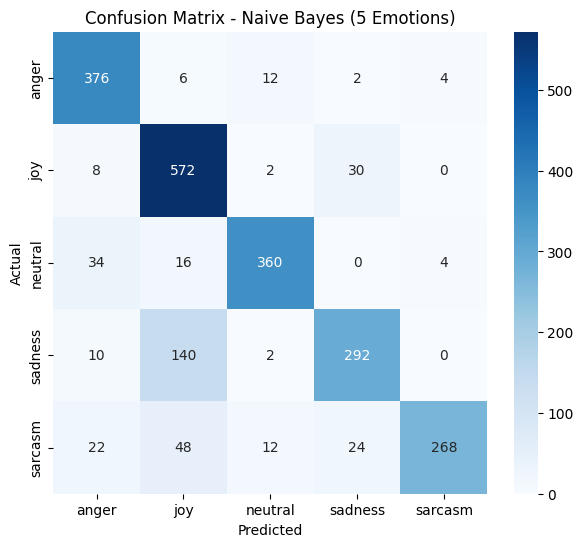

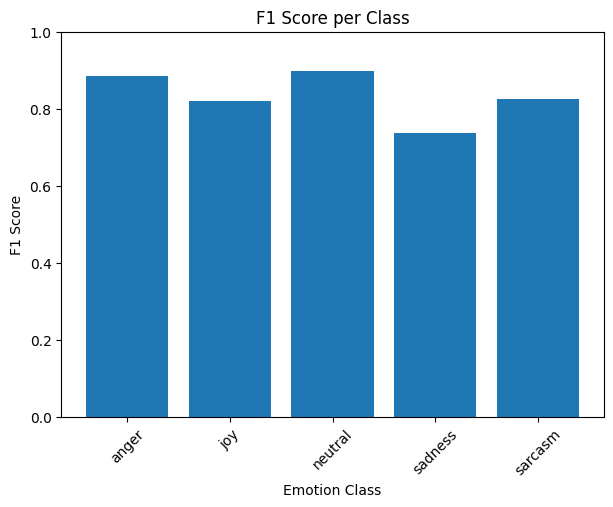


Performance Table:
  Class  Precision   Recall  F1-Score         Status
  anger   0.835556 0.940000  0.884706 High Performer
    joy   0.731458 0.934641  0.820660       Moderate
neutral   0.927835 0.869565  0.897756 High Performer
sadness   0.839080 0.657658  0.737374       Moderate
sarcasm   0.971014 0.716578  0.824615       Moderate

              TIMING SUMMARY
TF-IDF Vectorization  : 0.5976 sec
Model Training        : 0.0294 sec
Model Prediction      : 0.0014 sec
Training Speed        : 304228.55 sent/sec
Prediction Speed      : 1557507.56 sent/sec

Done.


In [7]:
# ============================================================
# NAIVE BAYES (TF-IDF + MultinomialNB)
# Kaggle-ready script for 5 emotions + F1 graph + performance table
# INCLUDES TRAINING TIME + SENTENCES/SEC METRICS
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import time  # ADDED FOR TIMING

print("Starting Naive Bayes Pipeline...")

# -----------------------------
# LOAD DATA
# -----------------------------
TRAIN_PATH = "/kaggle/input/your-dataset/training_clean.csv"
TEST_PATH  = "/kaggle/input/your-dataset/testing_clean.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

train_texts = df_train["text"].astype(str).tolist()
test_texts  = df_test["text"].astype(str).tolist()

y_train = df_train["label"].astype(str).values
y_test  = df_test["label"].astype(str).values

print(f"Train samples: {len(train_texts)}")
print(f"Test samples :  {len(test_texts)}")

# -----------------------------
# TF-IDF + NAIVE BAYES WITH TIMING
# -----------------------------
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=30000,
    sublinear_tf=True
)

# Time the TF-IDF transformation
start_time = time.time()
X_train = vectorizer.fit_transform(train_texts)
X_test  = vectorizer.transform(test_texts)
tfidf_time = time.time() - start_time

# Time the model training
start_time = time.time()
clf = MultinomialNB()
clf.fit(X_train, y_train)
training_time = time.time() - start_time

# Time the prediction
start_time = time.time()
pred = clf.predict(X_test)
prediction_time = time.time() - start_time

# -----------------------------
# CALCULATE SENTENCES PER SECOND
# -----------------------------
training_sentences_per_sec = len(train_texts) / training_time
prediction_sentences_per_sec = len(test_texts) / prediction_time

# -----------------------------
# METRICS
# -----------------------------
accuracy = accuracy_score(y_test, pred)
macro_f1 = f1_score(y_test, pred, average="macro")
full_report = classification_report(y_test, pred, output_dict=True)

print("\n" + "="*50)
print("              PERFORMANCE RESULTS")
print("="*50)
print(f"Accuracy                    : {accuracy:.4f}")
print(f"Macro F1                    : {macro_f1:.4f}")
print(f"TF-IDF Transformation Time  : {tfidf_time:.2f} seconds")
print(f"Training Time               : {training_time:.2f} seconds")
print(f"Training Speed              : {training_sentences_per_sec:.2f} sentences/sec")
print(f"Prediction Time             : {prediction_time:.2f} seconds") 
print(f"Prediction Speed            : {prediction_sentences_per_sec:.2f} sentences/sec")
print(f"Total Samples Processed     : {len(train_texts) + len(test_texts)}")
print("\nClassification Report:")
print(classification_report(y_test, pred))

# -----------------------------
# CONFUSION MATRIX
# -----------------------------
labels = sorted(list(set(y_train)))

cm = confusion_matrix(y_test, pred, labels=labels)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Confusion Matrix - Naive Bayes (5 Emotions)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# F1 SCORE BAR GRAPH PER CLASS
# ============================================================

class_f1_scores = {label: full_report[label]["f1-score"] for label in labels}

plt.figure(figsize=(7, 5))
plt.bar(class_f1_scores.keys(), class_f1_scores.values())
plt.title("F1 Score per Class")
plt.xlabel("Emotion Class")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

# ============================================================
# PERFORMANCE TABLE
# ============================================================

rows = []
for label in labels:
    precision = full_report[label]["precision"]
    recall = full_report[label]["recall"]
    f1 = full_report[label]["f1-score"]

    if f1 >= 0.85:
        status = "High Performer"
    elif f1 >= 0.70:
        status = "Moderate"
    else:
        status = "Mixed/Weak"

    rows.append([label, precision, recall, f1, status])

performance_df = pd.DataFrame(
    rows,
    columns=["Class", "Precision", "Recall", "F1-Score", "Status"]
)

print("\nPerformance Table:")
print(performance_df.to_string(index=False))

# ============================================================
# TIMING SUMMARY
# ============================================================
print("\n" + "="*50)
print("              TIMING SUMMARY")
print("="*50)
print(f"TF-IDF Vectorization  : {tfidf_time:.4f} sec")
print(f"Model Training        : {training_time:.4f} sec")
print(f"Model Prediction      : {prediction_time:.4f} sec")
print(f"Training Speed        : {training_sentences_per_sec:.2f} sent/sec")
print(f"Prediction Speed      : {prediction_sentences_per_sec:.2f} sent/sec")
print("="*50)

print("\nDone.")

In [5]:
# ============================================================
# INSTALL
# ============================================================
!pip install -q transformers sentencepiece

# ============================================================
# IMPORTS
# ============================================================
import torch
import numpy as np
import pandas as pd
from transformers import BertTokenizer, BertModel
from tqdm import tqdm
import os

# ============================================================
# CONFIG
# ============================================================
MODEL_PATH = "/kaggle/input/mbert-model"   # <-- LOCAL MBERT FOLDER
MAX_LEN = 64
BATCH_SIZE = 32

TRAIN_PATH = "/kaggle/input/your-dataset/training_clean.csv"
TEST_PATH  = "/kaggle/input/your-dataset/testing_clean.csv"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Check files to confirm
print("Local mBERT files:", os.listdir(MODEL_PATH))

# ============================================================
# LOAD LOCAL MODEL + TOKENIZER
# ============================================================
tokenizer = BertTokenizer.from_pretrained(MODEL_PATH)
model = BertModel.from_pretrained(MODEL_PATH)
model.to(DEVICE)
model.eval()

# ============================================================
# POOLING FUNCTIONS
# ============================================================
def mean_squared_pooling(hidden_states, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
    squared = hidden_states ** 2
    masked = squared * mask
    summed = torch.sum(masked, dim=1)
    count = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / count

def mean_pooling(hidden_states, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
    masked = hidden_states * mask
    summed = torch.sum(masked, dim=1)
    count = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / count

def max_pooling(hidden_states, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
    masked = hidden_states.masked_fill(mask == 0, -1e9)
    return torch.max(masked, dim=1).values

def cls_pooling(hidden_states):
    return hidden_states[:, 0, :]

# ============================================================
# BATCH EMBEDDING FUNCTION
# ============================================================
def create_embeddings_batch(texts, batch_size=32):
    emb_ms = []
    emb_multi = []
    emb_cls = []

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Batches"):
            try:
                batch_texts = texts[i:i+batch_size]

                if not batch_texts:
                    continue

                inputs = tokenizer(
                    batch_texts,
                    padding="max_length",
                    truncation=True,
                    max_length=MAX_LEN,
                    return_tensors="pt"
                ).to(DEVICE)

                outputs = model(**inputs)
                hidden = outputs.last_hidden_state

                ms = mean_squared_pooling(hidden, inputs['attention_mask'])
                m  = mean_pooling(hidden, inputs['attention_mask'])
                mx = max_pooling(hidden, inputs['attention_mask'])
                c  = cls_pooling(hidden)

                multi = torch.cat([m, mx, c], dim=1)

                emb_ms.extend(ms.cpu().numpy())
                emb_multi.extend(multi.cpu().numpy())
                emb_cls.extend(c.cpu().numpy())

            except Exception as e:
                print(f"❌ Error in batch {i}: {e}")
                continue

    return (
        np.array(emb_ms),
        np.array(emb_multi),
        np.array(emb_cls),
    )

# ============================================================
# LOAD DATA
# ============================================================
df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

train_texts = df_train["text"].astype(str).tolist()
test_texts  = df_test["text"].astype(str).tolist()

print("Train samples:", len(train_texts))
print("Test samples:", len(test_texts))

# ============================================================
# GENERATE EMBEDDINGS
# ============================================================
train_ms, train_multi, train_cls = create_embeddings_batch(train_texts)
test_ms,  test_multi,  test_cls  = create_embeddings_batch(test_texts)

print("\nShapes:")
print("Mean-Squared:", train_ms.shape, test_ms.shape)
print("Multi:", train_multi.shape, test_multi.shape)
print("CLS:", train_cls.shape, test_cls.shape)

# ============================================================
# SAVE OUTPUT
# ============================================================
np.save("mbert_train_mean_squared.npy", train_ms)
np.save("mbert_test_mean_squared.npy", test_ms)

np.save("mbert_train_mean_max_cls.npy", train_multi)
np.save("mbert_test_mean_max_cls.npy", test_multi)

np.save("mbert_train_cls.npy", train_cls)
np.save("mbert_test_cls.npy", test_cls)

print("✅ All embeddings saved successfully!")


Using device: cuda
Local mBERT files: ['config.json', 'tokenizer.json', 'tokenizer_config.json', 'pytorch_model.bin', 'model.safetensors', 'vocab.txt']
Train samples: 8954
Test samples: 2244


Batches: 100%|██████████| 71/71 [00:07<00:00,  9.03it/s]



Shapes:
Mean-Squared: (8954, 768) (2244, 768)
Multi: (8954, 2304) (2244, 2304)
CLS: (8954, 768) (2244, 768)
✅ All embeddings saved successfully!


In [8]:
# =============================================================
# IMPORTS
# =============================================================
import numpy as np
import pandas as pd
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from io import StringIO
import base64

# =============================================================
# LOAD EMBEDDINGS
# =============================================================
embeddings = {
    "mean_squared": {
        "train": np.load("mbert_train_mean_squared.npy"),
        "test":  np.load("mbert_test_mean_squared.npy")
    },
    "cls": {
        "train": np.load("mbert_train_cls.npy"),
        "test":  np.load("mbert_test_cls.npy")
    },
    "multi": {
        "train": np.load("mbert_train_mean_max_cls.npy"),
        "test":  np.load("mbert_test_mean_max_cls.npy")
    }
}

df_train = pd.read_csv("/kaggle/input/your-dataset/training_clean.csv")
df_test  = pd.read_csv("/kaggle/input/your-dataset/testing_clean.csv")

y_train = df_train["label"]
y_test  = df_test["label"]

label_names = ["ANGER", "JOY", "NEUTRAL", "SADNESS", "SARCASM"]

# =============================================================
# HELPERS — Convert matplotlib image → HTML <img>
# =============================================================
def fig_to_html():
    tmpfile = StringIO()
    plt.savefig("tmp.png", bbox_inches='tight')
    plt.close()
    with open("tmp.png", "rb") as f:
        encoded = base64.b64encode(f.read()).decode()
    return f'<img src="data:image/png;base64,{encoded}" style="width:400px;">'

# =============================================================
# TRAIN + EVALUATE SVM
# =============================================================
def evaluate_svm(X_train, X_test, y_train, y_test, kernel_name):
    if kernel_name == "linear":
    model = LinearSVC(
        C=0.5,
        max_iter=30000,
        dual=False  # recommended when n_samples > n_features
    )

    else:
        model = SVC(kernel="rbf", C=2, gamma="scale")

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    report = classification_report(y_test, preds, target_names=label_names)

    # --- Confusion matrix ---
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"Confusion Matrix — {kernel_name.upper()}")
    cm_html = fig_to_html()

    # --- F1 Histogram ---
    f1_scores = f1_score(y_test, preds, average=None)
    plt.figure(figsize=(6,3))
    plt.bar(label_names, f1_scores)
    plt.title(f"F1 per Class — {kernel_name.upper()}")
    plt.xticks(rotation=45)
    f1_html = fig_to_html()

    return acc, f1, report, cm_html, f1_html


# =============================================================
# GENERATE ONE BIG HTML FILE
# =============================================================
html_output = "<h1>SVM Results (All Embeddings × Both Kernels)</h1>"

for embed_name, data in embeddings.items():
    X_train = data["train"]
    X_test  = data["test"]

    html_output += f"<hr><h2>Embedding Type: {embed_name.upper()}</h2>"

    # ------- Linear SVM -------
    acc, f1, report, cm_img, f1_img = evaluate_svm(
        X_train, X_test, y_train, y_test, kernel_name="linear"
    )
    html_output += f"""
    <h3>Linear SVM</h3>
    <b>Accuracy:</b> {acc:.4f}<br>
    <b>Macro F1:</b> {f1:.4f}<br>
    <pre>{report}</pre>
    <h4>Confusion Matrix</h4>
    {cm_img}
    <h4>F1 Scores</h4>
    {f1_img}
    """

    # ------- RBF SVM -------
    acc, f1, report, cm_img, f1_img = evaluate_svm(
        X_train, X_test, y_train, y_test, kernel_name="rbf"
    )
    html_output += f"""
    <h3>RBF SVM</h3>
    <b>Accuracy:</b> {acc:.4f}<br>
    <b>Macro F1:</b> {f1:.4f}<br>
    <pre>{report}</pre>
    <h4>Confusion Matrix</h4>
    {cm_img}
    <h4>F1 Scores</h4>
    {f1_img}
    """

# =============================================================
# SAVE HTML
# =============================================================
with open("svm_all_results.html", "w", encoding="utf-8") as f:
    f.write(html_output)

print("✅ HTML file generated: svm_all_results.html")


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.



✅ HTML file generated: svm_all_results.html
